In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [4]:
# carichiamo il dataset reels con le feature create nel notebook2
reels = pd.read_csv("/kaggle/input/datasets/filippotenani/uniting-reels-engineered/uniting_reels_engineered.csv")

In [5]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'ENGAGE_RATE', 'COMM_PER_LIKE'],
      dtype='object')

# EXPLORATORY DATA ANALYSIS

The goal of this section is to explore the dataset to understand how the various columns are distributed, and we also want to understand which columns are most correlated with the targets and therefore more relevant to keep for the models.

For reels we use engagement_rate as the main target.

## CREATOR GENDER

In [ ]:
# barplot
reels["Creator_gender"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Creator_gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Female creators are the most present in the dataset. The least present are groups

In [ ]:
# boxplot di Creator_gender vs target
reels.boxplot(column="ENGAGE_RATE", by="Creator_gender", figsize=(10, 6))
plt.title("Engagement Rate per Genere")
plt.suptitle("")
plt.xlabel("Creator_gender")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

Male creators have a higher average engagement rate, followed by females and lastly groups. Males also show greater variability with more extreme outliers, suggesting that top performers are mostly males. Females have a more compact and predictable distribution.

## FOLLOWERS

In [ ]:
# istogramma per tipo di contenuto (tiktok vs instagram reels)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True, sharex=True)

for ax, tipo in zip(axes, ["INSTAGRAM_REEL", "TIKTOK_POST"]):
    reels[reels["Type of content"] == tipo]["Followers"].plot(
        kind="hist", bins=80, edgecolor="black", alpha=0.8, ax=ax
    )
    ax.set_title(f"Distribuzione Followers - {tipo}", fontsize=14)
    ax.set_xlabel("Numero di Followers", fontsize=12)

axes[0].set_ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
reels[reels["Type of content"] == "INSTAGRAM_REEL"]["Followers"].describe()

In [ ]:
reels[reels["Type of content"] == "TIKTOK_POST"]["Followers"].describe()

For both reels and tiktok we see that 75% of influencers in the dataset are below 700k followers and 50% of creators are below 300k followers. In particular we notice that the bottom 25% on tiktok has far fewer followers (42k) compared to the bottom 25% on instagram (148k). Also tiktok has a higher standard deviation

In [ ]:
# istogrammi follower per Creator_gender
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for ax, genere in zip(axes, ["f", "m", "o"]):
    reels[reels["Creator_gender"] == genere]["Followers"].plot(
        kind="hist", bins=80, edgecolor="black", alpha=0.8, ax=ax
    )
    ax.set_title(f"Followers - {genere}", fontsize=14)
    ax.set_xlabel("Numero di Followers", fontsize=11)

axes[0].set_ylabel("Frequenza", fontsize=11)
plt.tight_layout()
plt.show()

The distribution of followers is similar for males, females and groups, with a general concentration of creators at low follower counts; however, for groups this initial peak is much higher relative to the rest of their distribution than it is for the other two categories. Also for groups this peak is very narrow, while for males and females it is wider/more spread out.

In [ ]:
# scatterplot followers vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="Followers", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["Followers"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["Followers"], m * reels["Followers"] + b, color="red")

corr = reels["Followers"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The correlation between engagement rate and followers is negative but almost zero. This flattening is expected, since the engagement rate neutralizes the creator's size from the start by placing reach at the denominator. However, the slight negative trend confirms a well-known marketing phenomenon: smaller creators' communities are proportionally much more interactive and loyal.

## TYPE OF CONTENT

In [ ]:
# barplot
reels["Type of content"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Type of content")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We see that about 70% of posts are instagram reels while only 30% are tiktok posts. If we also consider instagram stories (not present in this dataset, but in the other dataset since we separated stories from tiktok/posts), they represent the largest amount of posts overall (about 2/3 of total content).

In [ ]:
# boxplot di Type of content vs target
reels.boxplot(column="ENGAGE_RATE", by="Type of content", figsize=(10, 6))
plt.title("Engagement Rate per Genere")
plt.suptitle("")
plt.xlabel("Type of content")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

We notice that tiktok posts have a much higher engagement rate compared to instagram posts, and they also have a much higher variance and median of engagement than instagram posts. This is in line with what we can read in some articles like the one presented below, which show that tiktok has a higher engagement rate compared to instagram:

https://www.socialinsider.io/social-media-benchmarks

## POST CREATION DATE / MESE

To visualize post_creation_date we use the variable mese that we created specifically earlier.

In [ ]:
# barplot
reels["mese"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("mese")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We see that in May, June, July and in autumn the largest quantity of reels is published. Contrary to what we expected, the winter months (which therefore include Christmas and New Year's), the Easter period (March, April) and August are the months with the fewest posts overall.

In [ ]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="mese", figsize=(10, 6))
plt.xlabel("Mese")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

September, July, May, January and February show the highest engagement medians of the year. October, November, January and May stand out for the most extreme absolute maximum peaks, while August, April and December record the lowest median values overall.

Comparing this chart with the previous one, it emerges that the months with fewer posts (August, April and December) indeed correspond to the lowest engagement of the year. On the contrary, the high publication frequency between May, July and autumn is amply rewarded, coinciding with the best interaction rates and absolute maximum peaks. The real exception is winter: although very little is published in January and February, these months record excellent engagement medians, showing a possible missed opportunity for creators.

## WEEKEND

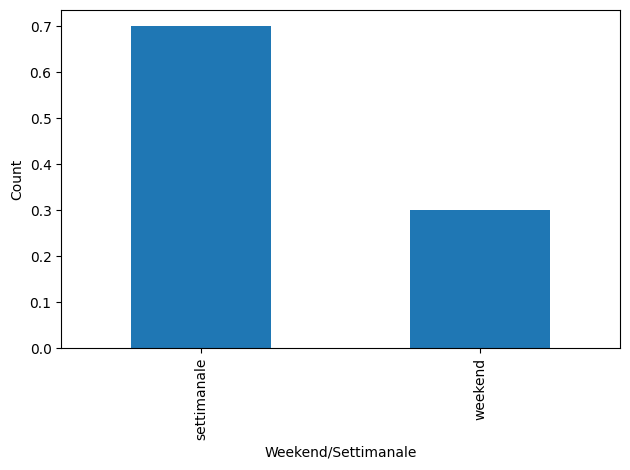

In [5]:
# barplot
reels["Weekend/Settimanale"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Weekend/Settimanale")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We see that 70% of posts are on weekdays, 30% are on the weekend (in which we included Friday because we consider Friday evening as the start of the weekend).

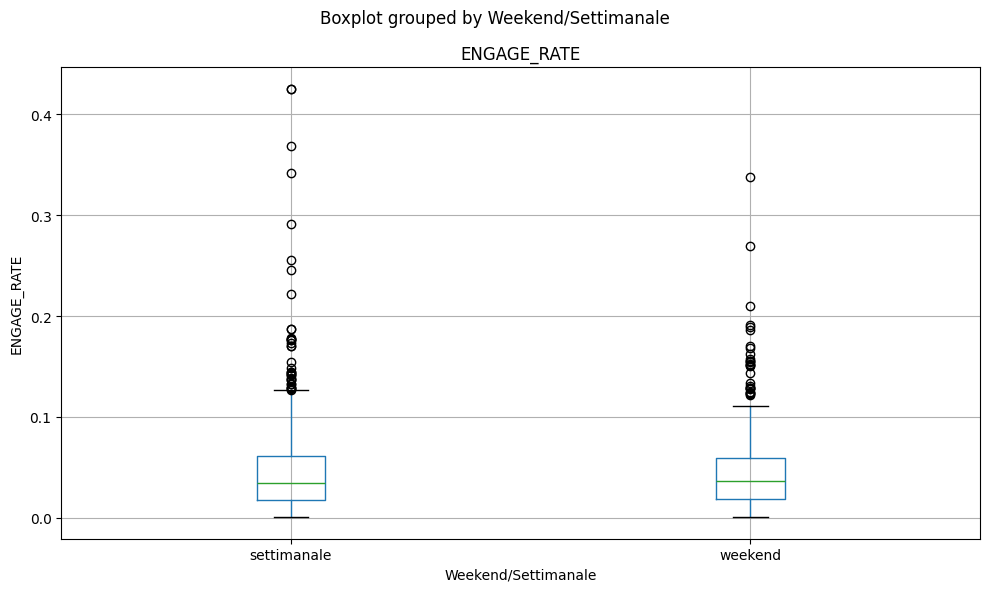

In [6]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="Weekend/Settimanale", figsize=(10, 6))
plt.xlabel("Weekend/Settimanale")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

Surprisingly, the engagement rate is practically identical between weekdays and weekends.

## POST CREATION TIME / FASCIA ORARIA

To visualize post_creation_time we use the variable fascia_oraria that we created specifically earlier.

In [ ]:
# barplot
reels["fascia_oraria"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("fascia_oraria")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Almost half of posts are published at lunchtime. The afternoon also sees a significant amount of publications (almost 30%) and also the dinner hours a bit (almost 20%), while evening and morning see about 6% of posts overall.

In [ ]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="fascia_oraria", figsize=(10, 6))
plt.xlabel("fascia_oraria")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

The median of engagement rate is roughly similar across the various time slots. The only exceptions are evening and afternoon which have a lower median. This is strange for the afternoon since creators post a lot in this time slot. The evening has the widest box overall, showing the greatest variability of engagement.

## REACH, LIKES, COMMENTS

In [ ]:
# histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

reels["Reach"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[0])
axes[0].set_xlabel("Reach", fontsize=12)
axes[0].set_ylabel("Frequenza", fontsize=12)

reels["Likes"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_xlabel("Likes", fontsize=12)

reels["Comments"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[2])
axes[2].set_xlabel("Comments", fontsize=12)

plt.tight_layout()
plt.show()

In Reels the reach and likes show distributions skewed toward the bottom, but characterized by rare extreme peaks reaching approximately 30 million and 160k respectively. Despite this vast potential coverage, the squashing of comments toward zero highlights the difficulty in converting passive exposure into comments.

This greater difficulty of users to leave comments compared to likes was studied in the previous notebook, allowing us to determine weights that quantify how much greater the effort of users to comment is compared to leaving a like.

We do not visualize how these variables vary with respect to the target, because they themselves compose the target.

## BRAND NAME

In [ ]:
# barplot
fig, axes = plt.subplots(1, figsize=(18, 6))
reels["Brand name"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Brand name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Amazon is by far the most present brand, followed by Vileda. Then come Decathlon, Bennet, Esselunga and Supradyn. The interesting thing is that Amazon is much more present in this reels dataset, while the stories dataset was clearly dominated by Vileda.

In [ ]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="Brand name", figsize=(18, 6))
plt.xlabel("Brand name")
plt.ylabel("ENGAGE_RATE")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

We notice that the most present brands are not those with the highest engagement rate, those that lead to the most interactions are in fact Ferrari, Brunello Cucinelli and Prada; in practice luxury brands generate higher engagement.

Looking back at the frequency chart, these three brands have very low presence, so their high engagement rate may also be due to the fact that they sponsor their products less frequently but in a very targeted way.

## INDUSTRY

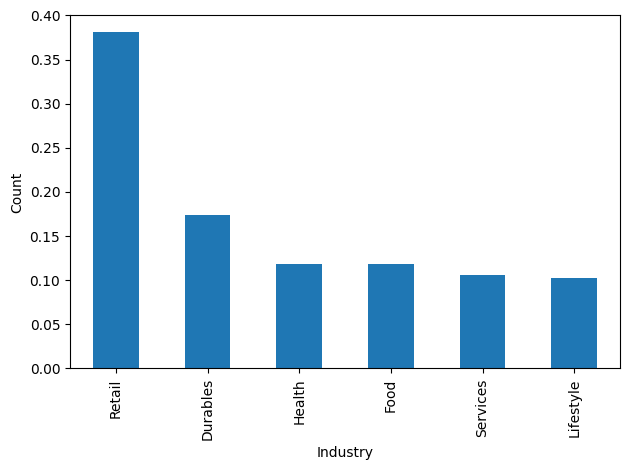

In [9]:
# barplot
reels["Industry"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The clearly most present industry is retail, the other 5 instead have a fairly similar frequency around 10-15% each.

In [ ]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="Industry", figsize=(10, 6))
plt.xlabel("Industry")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

Despite being the most present in the dataset, the retail industry does not have the highest engagement rate; this position belongs instead to lifestyle which has higher engagement than all other industries, while food has the lowest.

## LOCAL

In [ ]:
# barplot
reels["Local"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Local")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

More than 60% of sponsorships are done by non-local brands.

In [ ]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="Local", figsize=(10, 6))
plt.xlabel("Local")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

Engagement is practically the same between local and non-local brands, non-local brands have a slightly higher median probably because they are more famous and recognized international brands.

## BRAND SM

In [ ]:
# histogram
# ci sono quasi tutti valori bassi tranne pochissimi outlier estremi che rendono difficile vedere la scala per valori bassi
# so we plot two charts, one with outliers to see them too and one without to better see the low values
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

reels["Brand_SM"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[0])
axes[0].set_xlabel("Brand_SM", fontsize=12)
axes[0].set_ylabel("Frequenza", fontsize=12)

reels["Brand_SM"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_xlabel("Brand_SM", fontsize=12)
axes[1].set_ylabel("Frequenza", fontsize=12)
axes[1].set_xlim(0, 2_000_000)

plt.tight_layout()
plt.show()

The vast majority of brands are concentrated below 500,000 followers, while rare giants above 30 million create an asymmetry that distorts the perception of the dataset. This clear gap confirms that collaborations mainly occur with small-to-medium sized entities in terms of followers.

Despite Amazon doing many sponsorships, its follower count is 456k so according to this metric it does not fall among the large brands.

In [ ]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="Brand_SM", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["Brand_SM"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["Brand_SM"], m * reels["Brand_SM"] + b, color="red")

corr = reels["Brand_SM"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The brand's social media follower count is positively correlated with engagement rate, so more recognized brands push users to interact more.

## MEDIA DURATION SEC

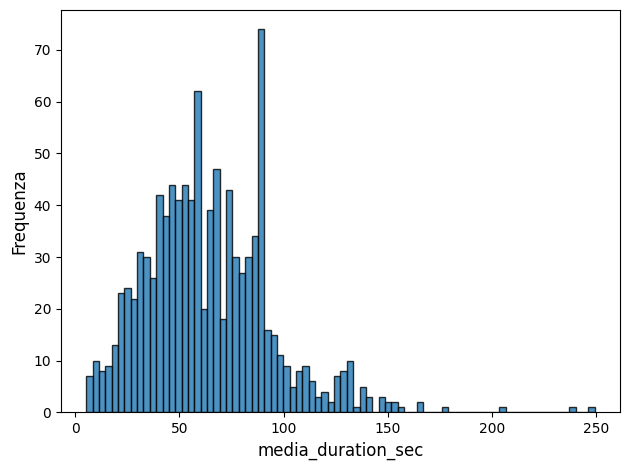

In [6]:
# histogram
reels["media_duration_sec"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("media_duration_sec", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

The distribution shows a strong presence of videos with duration between 40 and 90 seconds, with a tail that extends up to 250 seconds.

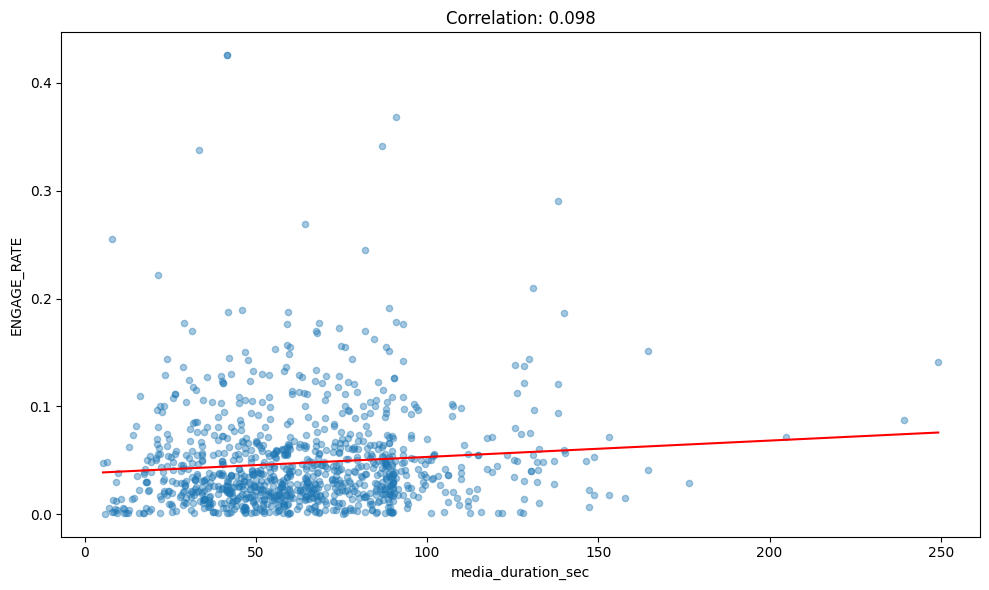

In [14]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="media_duration_sec", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["media_duration_sec"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["media_duration_sec"], m * reels["media_duration_sec"] + b, color="red")

corr = reels["media_duration_sec"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The duration of a reel is positively correlated with the video's own engagement, probably because the algorithm rewards watch time and completion rate as quality signals.

## FACE FRAME RATIO

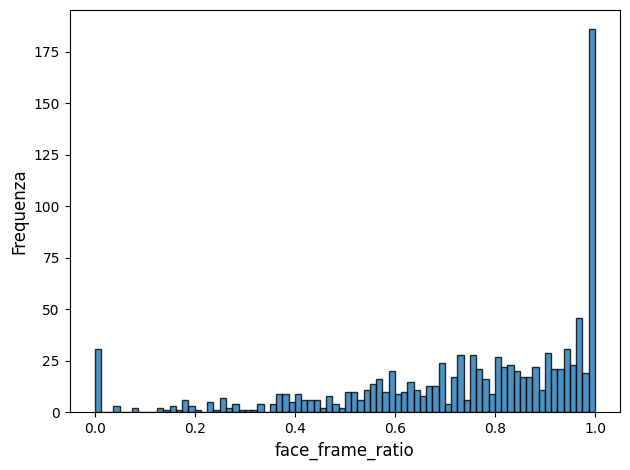

In [15]:
# histogram
reels["face_frame_ratio"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("face_frame_ratio", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

The vast majority of reels show a face for 100% of the reel, in particular the frequency of observations in the dataset increases as the percentage of reel containing the face increases. A small peak occurs at 0, meaning videos without a face.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


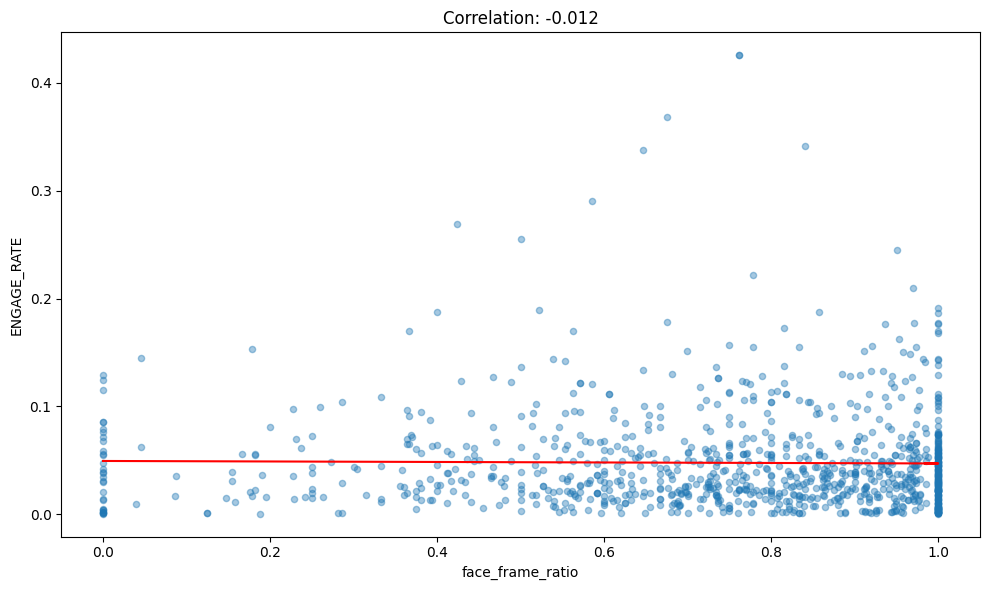

In [16]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="face_frame_ratio", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["face_frame_ratio"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["face_frame_ratio"], m * reels["face_frame_ratio"] + b, color="red")

corr = reels["face_frame_ratio"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

We can nee that the correlation is negative but basically flat, so showing the face for longer during the video has a negative or negligeable impact on enaggement.

## FACE

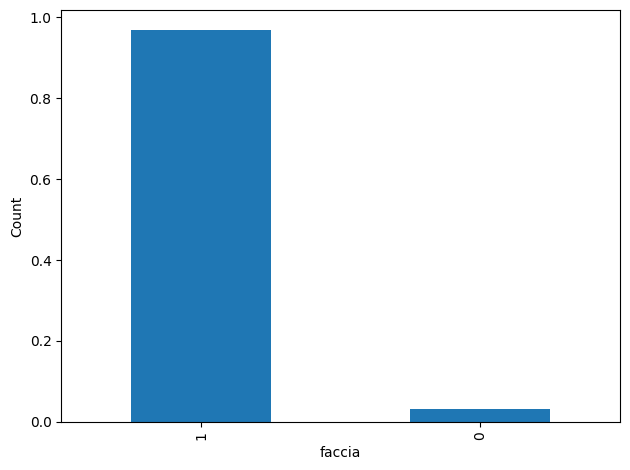

In [17]:
# barplot
reels["faccia"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("faccia")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [19]:
reels["faccia"].value_counts(normalize=True)

faccia
1    0.969398
0    0.030602
Name: proportion, dtype: float64

We can observe that 97% of reels have a face in them.

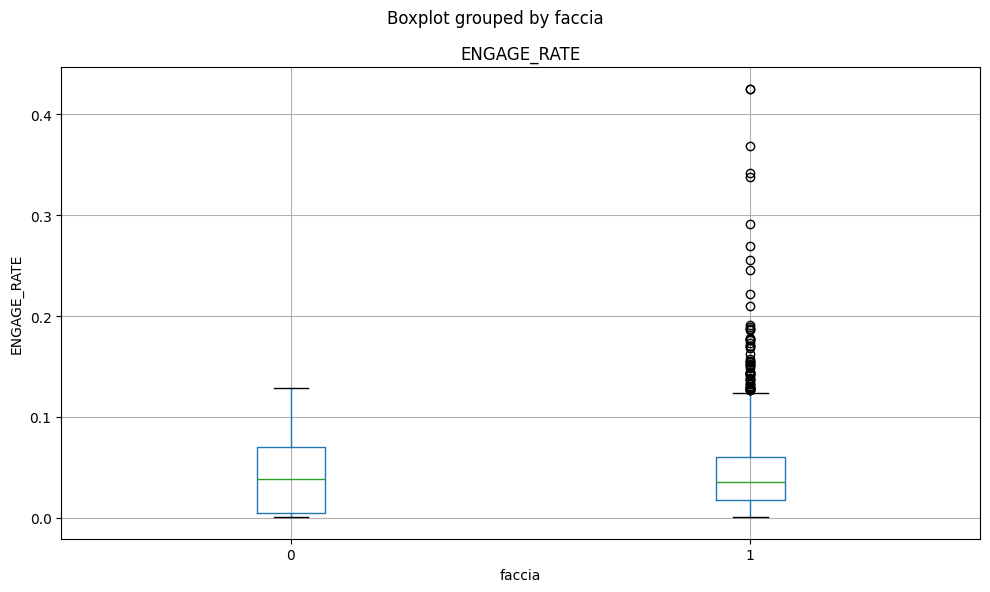

In [20]:
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="faccia", figsize=(10, 6))
plt.xlabel("faccia")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

Although the median engagement values are similar between the two groups, reels with a face demonstrate a clearly superior virality potential, populating the upper part of the chart with numerous high-performance outliers.

## FIRST FACE POSITION RATIO

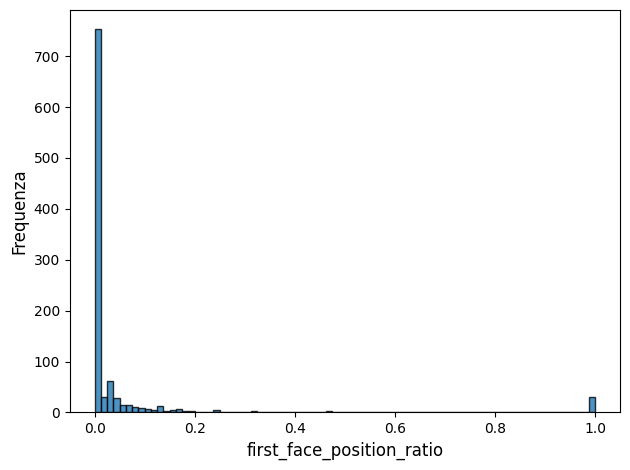

In [21]:
# histogram
reels["first_face_position_ratio"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("first_face_position_ratio", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

In practically all reels the face appears exactly at the beginning, in the first frame. A very small peak occurs for first_face_position_ratio=1 which is the value we use as a proxy to indicate that the video has no face.

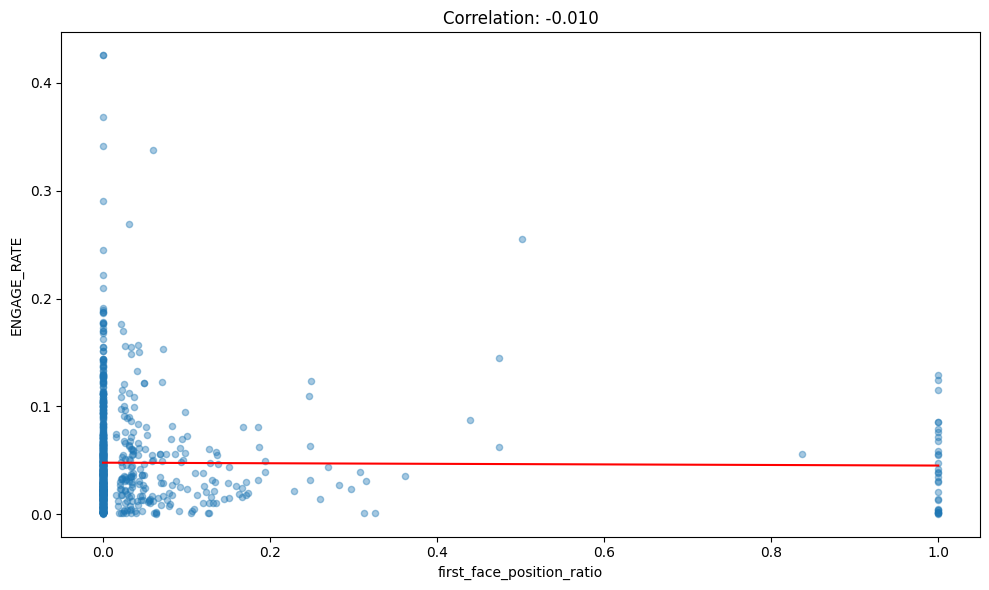

In [22]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="first_face_position_ratio", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["first_face_position_ratio"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["first_face_position_ratio"], m * reels["first_face_position_ratio"] + b, color="red")

corr = reels["first_face_position_ratio"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The correlation between first_face_position_ratio and engagement is practically flat, meaning that the frame in which the face is shown does not have a strong impact on engagement.

## VIDEO METRICS

Let's now analyze the features representing the video metrics:

'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity'

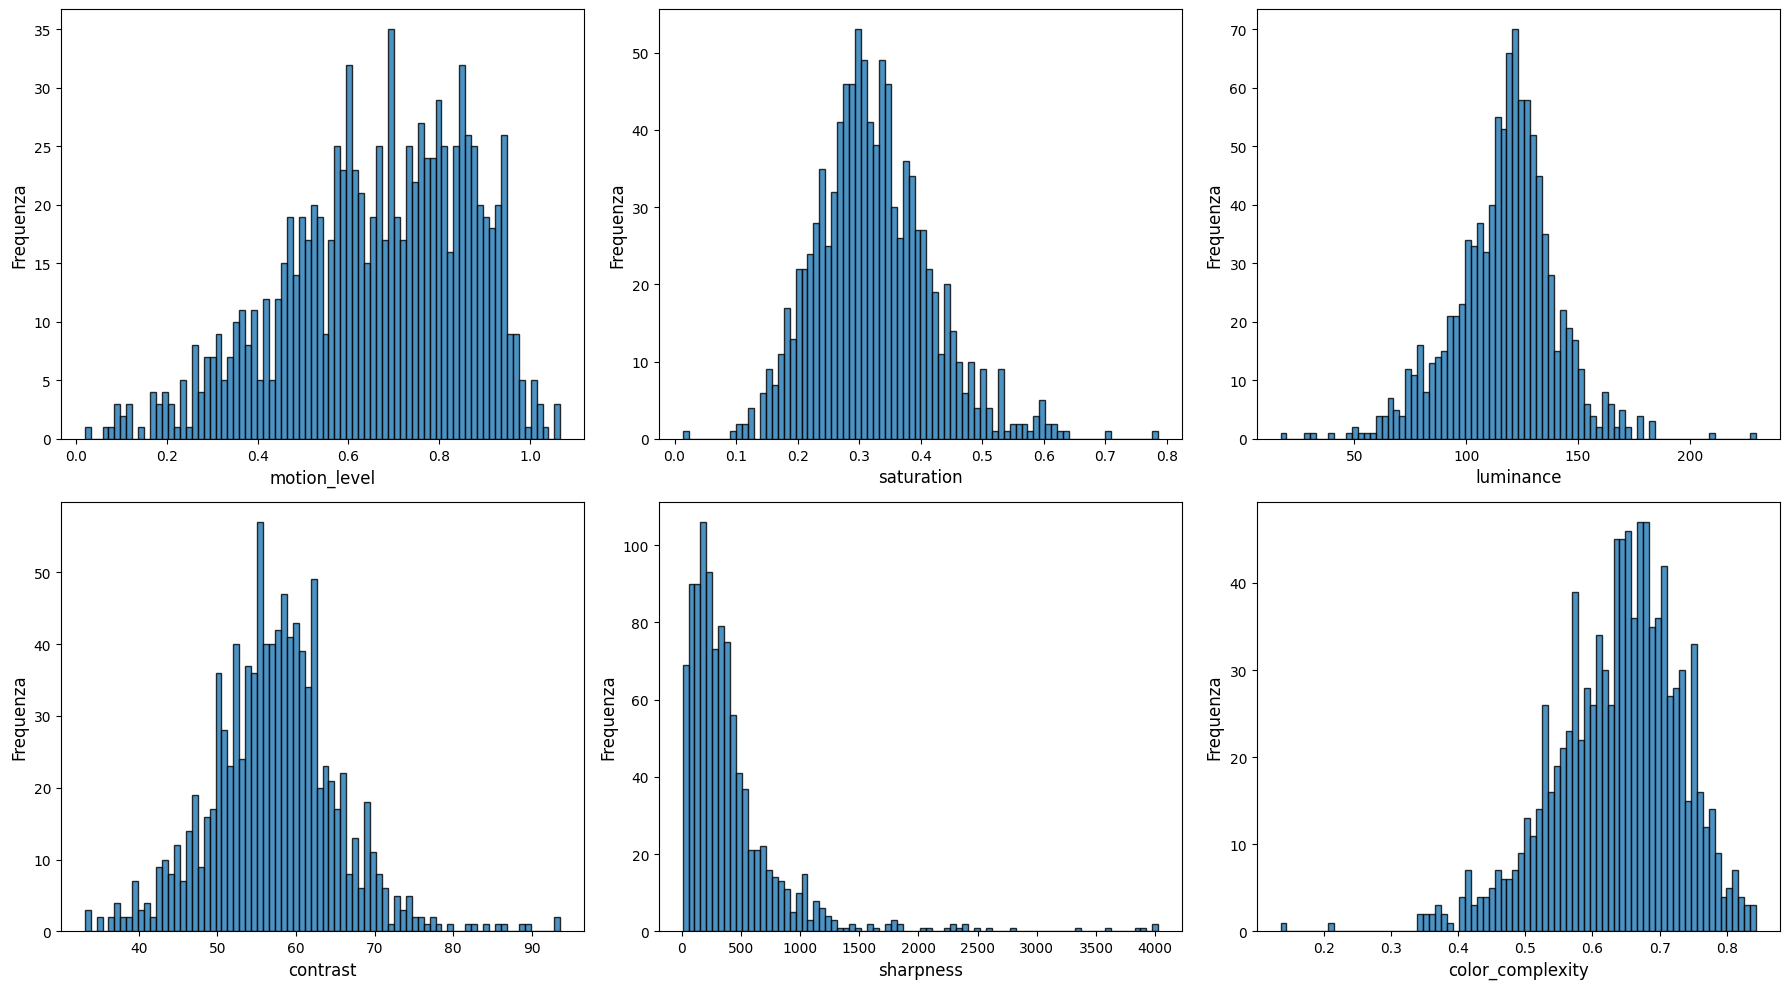

In [5]:
# histogram
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity']):
    reels[col].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=ax)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequenza", fontsize=12)

plt.tight_layout()
plt.show()

The distribution of motion_level is strongly skewed toward high values, confirming dynamism as the dominant characteristic of the dataset. Saturation, luminance and contrast show normal and well-centered distributions, while sharpness is generally low. Color_complexity is at very high values, indicating chromatically rich scenes.

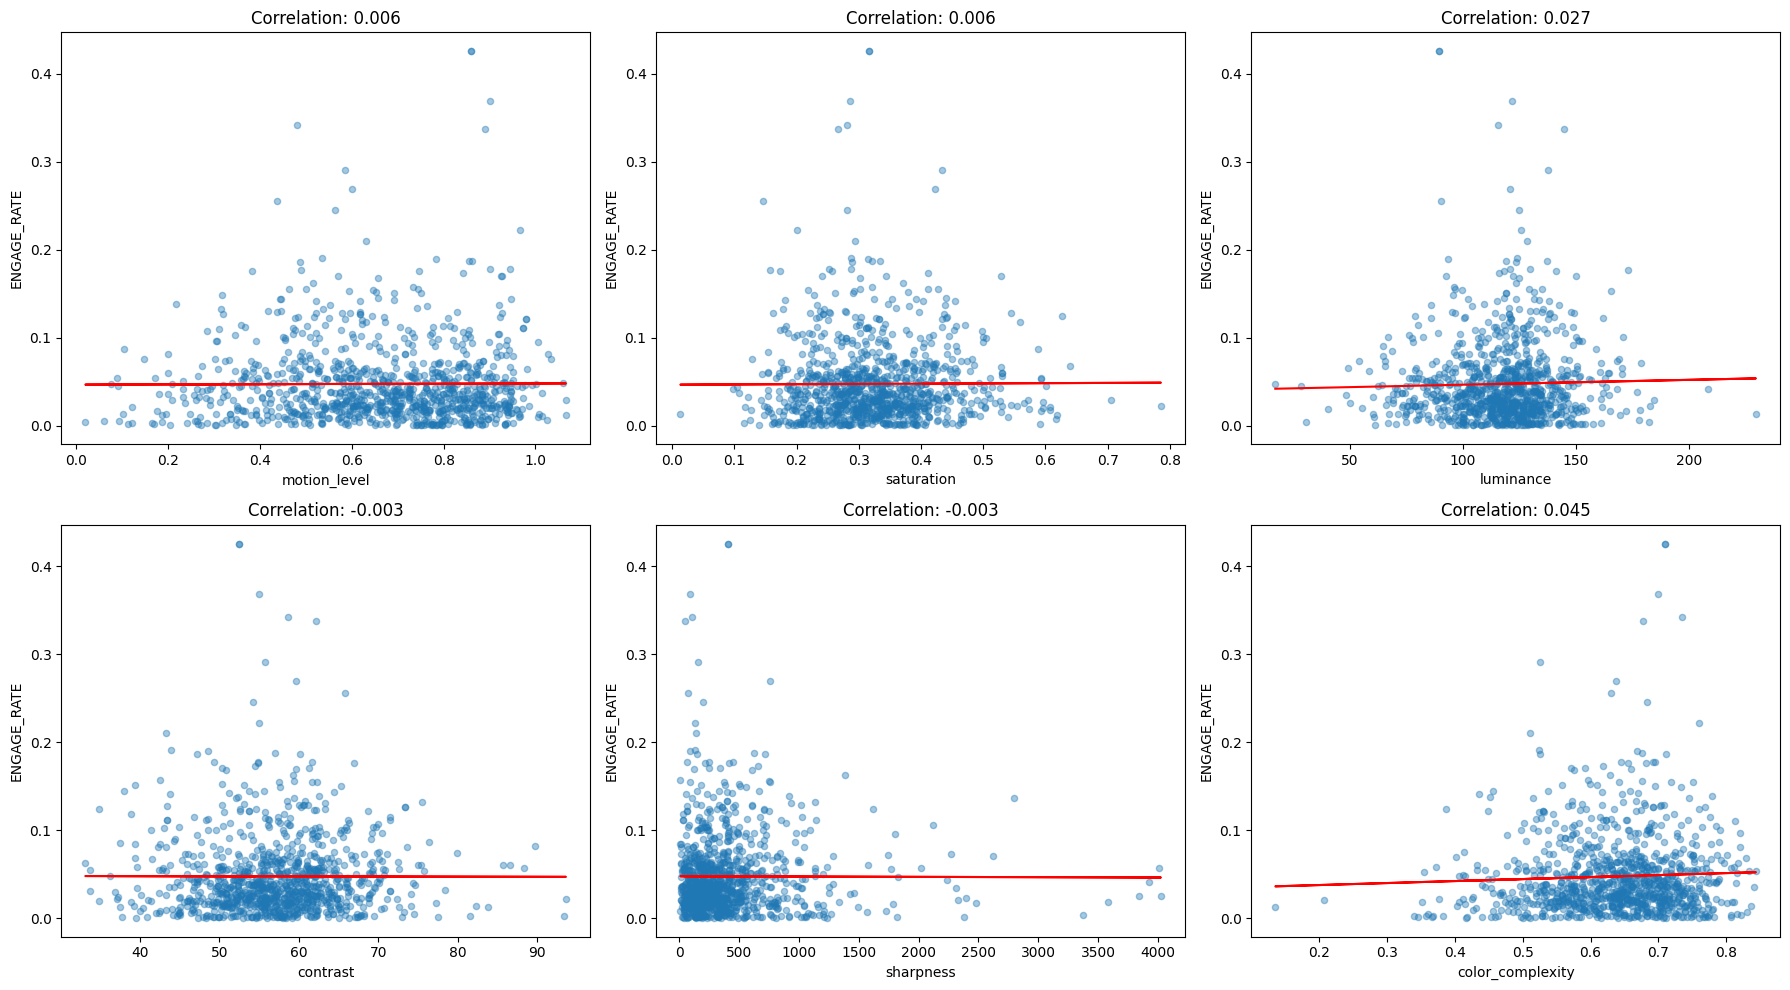

In [6]:
# scatterplot vs target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity']):
    reels.plot(kind="scatter", x=col, y="ENGAGE_RATE", alpha=0.4, ax=ax)
    m, b = np.polyfit(reels[col], reels["ENGAGE_RATE"], 1)
    ax.plot(reels[col], m * reels[col] + b, color="red")
    corr = reels[col].corr(reels["ENGAGE_RATE"])
    ax.set_title(f"Correlation: {corr:.3f}")

plt.tight_layout()
plt.show()

Contrast and sharpness are the only two variables negatively correlated with engagement rate, while the other four are positively correlated. In all six cases however the correlation is extremely close to zero, essentially indicating that these variables are uncorrelated with engagement.

It would not even make sense to do a PCA on these variables, because first of all we would get PCs that are very hard to interpret (they would be combinations of video metrics) and above all they would also be uncorrelated with the target since they are a linear combination of all variables uncorrelated with the target (we tried and indeed that's what happens).

In [ ]:
# COSE DA CHIARIRE/COMPLETARE MERCOLEDI:
# 1) Capire cosa fare con le metriche che sono scorrelate da target
# 2) Dobbiamo fare clustering (esempio: commenti + like + terza dimensione)
# 3) Sistemare dataset:
# - Dai reels rimuovere Total clicks, dalle stories rimuovere Comments e Likes
# - Togliere dai due dataset overload e flashiness e magari aggiunge le PC della PCA
# - Spiegare perche togliamo overload e flashiness e spiegare PCA ecc...
# - One hot encoding delle categoriche
# - Esportare dataset cosi modificati

In [5]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'ENGAGE_RATE', 'COMM_PER_LIKE'],
      dtype='object')

In [ ]:
# NUMERIC
# histogram
reels["Followers"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("Followers", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

# CATEGORICAL
# barplot
reels["Mese"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Mese")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# NUMERIC VS TARGET
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
reels.plot(kind="scatter", x="Followers", y="ENGAGE_RATE", alpha=0.4, ax=ax)

m, b = np.polyfit(reels["Followers"], reels["ENGAGE_RATE"], 1)
ax.plot(reels["Followers"], m * reels["Followers"] + b, color="red")

corr = reels["Followers"].corr(reels["ENGAGE_RATE"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

# CATEGORICAL VS TARGET
# boxplot vs target
reels.boxplot(column="ENGAGE_RATE", by="Mese", figsize=(10, 6))
plt.xlabel("Mese")
plt.ylabel("ENGAGE_RATE")
plt.tight_layout()
plt.show()

# REMOVE OUTLIERS
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="mese", figsize=(10, 6))
plt.xlabel("mese")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()